In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.preprocessing import OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error


In [69]:
df=pd.read_csv('insurance.csv')

In [70]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [85]:
df.shape

(1338, 7)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [73]:
df.describe(include=['object','number'])

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [74]:
X=df.drop(columns='charges')
y=df['charges']

In [75]:
nums_cols=X.select_dtypes(include='number').columns
obj_cols=X.select_dtypes(include='object').columns

<Axes: >

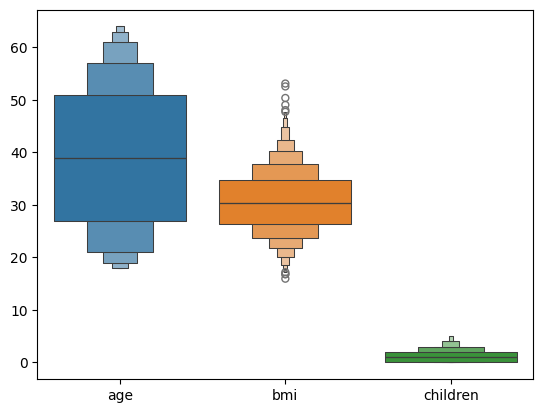

In [76]:
sns.boxenplot(X)

In [77]:
for col in nums_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1

    lower=Q1 -1.5 *IQR
    upper = Q3 + 1.5 *IQR

    outlier=df[(df[col]<lower) | (df[col]>upper)]

    print('\n' , col)
    print('lower:',lower)
    print('upper: ',upper)
    print('outlier: ',len(outlier))


 age
lower: -9.0
upper:  87.0
outlier:  0

 bmi
lower: 13.7
upper:  47.290000000000006
outlier:  9

 children
lower: -3.0
upper:  5.0
outlier:  0


In [78]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [79]:
preprocessor=ColumnTransformer(
    transformers=[
        ('min_scaler',MinMaxScaler(),['age','children']),
        ('std_scaler',StandardScaler(),['bmi']),
        ('encoder',OneHotEncoder(handle_unknown='ignore'),obj_cols)
    ]
)

In [80]:
main_pipe=Pipeline(
    steps=[
        ('preprocess',preprocessor),
        ('model',LinearRegression())
    ]
)

In [81]:
main_pipe.fit(Xtrain,ytrain)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('min_scaler', ...), ('std_scaler', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
ypred_train= main_pipe.predict(Xtrain)
ypred_test=main_pipe.predict(Xtest)

In [83]:
print("R² Score:", r2_score(ytrain, ypred_train))
print("MAE:", mean_absolute_error(ytrain, ypred_train))
print("RMSE:", root_mean_squared_error(ytrain, ypred_train))

R² Score: 0.7417255854683333
MAE: 4208.234572492221
RMSE: 6105.545160099848


In [84]:
print("R² Score:", r2_score(ytest, ypred_test))
print("MAE:", mean_absolute_error(ytest, ypred_test))
print("RMSE:", root_mean_squared_error(ytest, ypred_test))

R² Score: 0.7835929767120724
MAE: 4181.194473753645
RMSE: 5796.284659276273


`Linear Regression` achieved an R² of 0.784 on the test set with an MAE of approximately 4,181 and RMSE of approximately 5,796 . The training and testing performance are similar, indicating no obvious overfitting. The model provides a reasonable baseline for predicting insurance charges, although some prediction error remains.